# 15 - IDRiD preprocessing: tiling + masked arm

Turns the 54 train / 27 test full-resolution images (2848x4288) into 512x512 tiles with matching multi-class masks, for the four kept classes (Microaneurysms, Haemorrhages, Hard Exudates, Optic Disc). Builds both the **unmasked** and **masked** (radius-scaled 0.9) versions. Saves tiles as compressed arrays the training notebooks load directly.

Soft Exudates excluded (only 26 training images). Pixel accuracy is not used downstream: microaneurysms are ~0.076% of pixels, so an all-background prediction would score ~99.9%.

**Attach:** the IDRiD dataset. No GPU. Commit when done so the tiles attach to the training notebooks.

In [1]:
import os, numpy as np, cv2
from PIL import Image
Image.MAX_IMAGE_PIXELS=None

BASE='/kaggle/input/datasets/dankok/diabetic-retinopathy-image-dataset/Segmentation'
TRAIN_IMG=f'{BASE}/Original_Images/Training Set'
TEST_IMG =f'{BASE}/Original_Images/Testing Set'
MASK_TRAIN=f'{BASE}/Segmentation_Groundtruths/Training Set'
MASK_TEST =f'{BASE}/Segmentation_Groundtruths/Testing Set'

# class index map (0 = background, then one channel per class)
CLASSES=['Microaneurysms','Haemorrhages','Hard Exudates','Optic Disc']
SUFFIX ={'Microaneurysms':'MA','Haemorrhages':'HE','Hard Exudates':'EX','Optic Disc':'OD'}
TILE=512
print('classes:',CLASSES)

classes: ['Microaneurysms', 'Haemorrhages', 'Hard Exudates', 'Optic Disc']


## Radius-scaling mask (same as classification, factor 0.9)

In [2]:
def circle_mask_params(img_np, radius_factor=0.9):
    grey=cv2.cvtColor(img_np,cv2.COLOR_RGB2GRAY)
    _,th=cv2.threshold(grey,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    k=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(15,15))
    closed=cv2.morphologyEx(th,cv2.MORPH_CLOSE,k)
    cnts,_=cv2.findContours(closed,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return None
    (cx,cy),r=cv2.minEnclosingCircle(max(cnts,key=cv2.contourArea))
    return int(cx),int(cy),int(r*radius_factor)

def apply_circle(img_np, params):
    if params is None: return img_np
    cx,cy,r=params
    m=np.zeros(img_np.shape[:2],np.uint8); cv2.circle(m,(cx,cy),r,255,-1)
    return np.where(m[...,None]==255,img_np,0)

## Load one image + build its 4-channel mask stack

In [3]:
def load_image(img_dir, stem):
    p=os.path.join(img_dir, stem+'.jpg')
    return np.array(Image.open(p).convert('RGB'))

def load_mask_stack(mask_root, stem, H, W):
    """(H,W,4) binary stack in CLASSES order. Missing lesion -> all-zero channel."""
    stack=np.zeros((H,W,len(CLASSES)),np.uint8)
    for ci,cls in enumerate(CLASSES):
        folder=os.path.join(mask_root,cls)
        if not os.path.isdir(folder): continue
        cand=[f for f in os.listdir(folder) if f.startswith(stem) and f.lower().endswith(('.tif','.tiff'))]
        if cand:
            m=np.array(Image.open(os.path.join(folder,cand[0])))
            if m.ndim==3: m=m[...,0]
            stack[...,ci]=(m>0).astype(np.uint8)
    return stack

## Tiling with positive/negative sampling
Every tile containing any lesion pixel is kept. Background-only tiles are kept at a capped ratio so the model sees context without being swamped by empty sky.

In [4]:
def tile_image(img, mask_stack, tile=TILE, neg_per_pos=1, rng=None):
    H,W=img.shape[:2]
    rng=rng or np.random.default_rng(42)
    pos_img,pos_msk,neg_img,neg_msk=[],[],[],[]
    for y in range(0,H-tile+1,tile):
        for x in range(0,W-tile+1,tile):
            it=img[y:y+tile,x:x+tile]
            mt=mask_stack[y:y+tile,x:x+tile]
            # skip tiles that are almost all black background (outside fundus)
            if (it.sum(-1)>10).mean() < 0.2: continue
            if mt.any(): pos_img.append(it); pos_msk.append(mt)
            else: neg_img.append(it); neg_msk.append(mt)
    # cap negatives
    n_neg=min(len(neg_img), max(1,int(len(pos_img)*neg_per_pos)))
    if neg_img and n_neg>0:
        idx=rng.choice(len(neg_img),n_neg,replace=False)
        neg_img=[neg_img[i] for i in idx]; neg_msk=[neg_msk[i] for i in idx]
    else: neg_img,neg_msk=[],[]
    return pos_img+neg_img, pos_msk+neg_msk

## Build a split (train or test), both arms

In [5]:
def build_split(img_dir, mask_root, masked, neg_per_pos, tag):
    stems=sorted(os.path.splitext(f)[0] for f in os.listdir(img_dir) if f.endswith('.jpg'))
    X,Y=[],[]
    rng=np.random.default_rng(42)
    for i,st in enumerate(stems):
        img=load_image(img_dir,st); H,W=img.shape[:2]
        stack=load_mask_stack(mask_root,st,H,W)
        if masked:
            params=circle_mask_params(img,0.9)
            img=apply_circle(img,params)
            # zero mask outside the circle too, so we don't train on masked-away lesions
            if params is not None:
                cx,cy,r=params; cm=np.zeros((H,W),np.uint8); cv2.circle(cm,(cx,cy),r,1,-1)
                stack=stack*cm[...,None]
        tiles,masks=tile_image(img,stack,neg_per_pos=neg_per_pos,rng=rng)
        for t,m in zip(tiles,masks):
            X.append(cv2.resize(t,(TILE,TILE))); Y.append(m)
        if i%10==0: print(f'  {tag}: {i+1}/{len(stems)} images -> {len(X)} tiles')
    X=np.stack(X).astype(np.uint8); Y=np.stack(Y).astype(np.uint8)
    print(f'{tag}: {X.shape[0]} tiles, X{X.shape} Y{Y.shape}')
    return X,Y

## Run: build all four sets (train/test x unmasked/masked)
Test tiles use neg_per_pos high enough to cover the images densely for fair whole-image evaluation; here we tile the test set exhaustively over the fundus (neg cap large).

In [6]:
import numpy as np
OUT='/kaggle/working'
# TRAIN - balanced negatives
Xtr_u,Ytr_u=build_split(TRAIN_IMG,MASK_TRAIN,masked=False,neg_per_pos=1,tag='train/unmasked')
np.savez_compressed(f'{OUT}/idrid_train_unmasked.npz',X=Xtr_u,Y=Ytr_u)
Xtr_m,Ytr_m=build_split(TRAIN_IMG,MASK_TRAIN,masked=True,neg_per_pos=1,tag='train/masked')
np.savez_compressed(f'{OUT}/idrid_train_masked.npz',X=Xtr_m,Y=Ytr_m)
# TEST - denser coverage (more negatives) for realistic evaluation
Xte_u,Yte_u=build_split(TEST_IMG,MASK_TEST,masked=False,neg_per_pos=3,tag='test/unmasked')
np.savez_compressed(f'{OUT}/idrid_test_unmasked.npz',X=Xte_u,Y=Yte_u)
Xte_m,Yte_m=build_split(TEST_IMG,MASK_TEST,masked=True,neg_per_pos=3,tag='test/masked')
np.savez_compressed(f'{OUT}/idrid_test_masked.npz',X=Xte_m,Y=Yte_m)
print('saved all four npz files')

  train/unmasked: 1/54 images -> 39 tiles
  train/unmasked: 11/54 images -> 375 tiles
  train/unmasked: 21/54 images -> 704 tiles
  train/unmasked: 31/54 images -> 1031 tiles
  train/unmasked: 41/54 images -> 1356 tiles
  train/unmasked: 51/54 images -> 1686 tiles
train/unmasked: 1792 tiles, X(1792, 512, 512, 3) Y(1792, 512, 512, 4)
  train/masked: 1/54 images -> 28 tiles
  train/masked: 11/54 images -> 308 tiles
  train/masked: 21/54 images -> 591 tiles
  train/masked: 31/54 images -> 871 tiles
  train/masked: 41/54 images -> 1151 tiles
  train/masked: 51/54 images -> 1428 tiles
train/masked: 1513 tiles, X(1513, 512, 512, 3) Y(1513, 512, 512, 4)
  test/unmasked: 1/27 images -> 35 tiles
  test/unmasked: 11/27 images -> 417 tiles
  test/unmasked: 21/27 images -> 802 tiles
test/unmasked: 1011 tiles, X(1011, 512, 512, 3) Y(1011, 512, 512, 4)
  test/masked: 1/27 images -> 28 tiles
  test/masked: 11/27 images -> 320 tiles
  test/masked: 21/27 images -> 601 tiles
test/masked: 770 tiles, X(77

## Sanity: class pixel counts + a visual tile check

Per-class positive-pixel share in TRAIN (unmasked):
  Microaneurysms   0.1422% of tile pixels | tiles with class: 839
  Haemorrhages     1.1650% of tile pixels | tiles with class: 677
  Hard Exudates    1.1251% of tile pixels | tiles with class: 758
  Optic Disc       2.5250% of tile pixels | tiles with class: 203


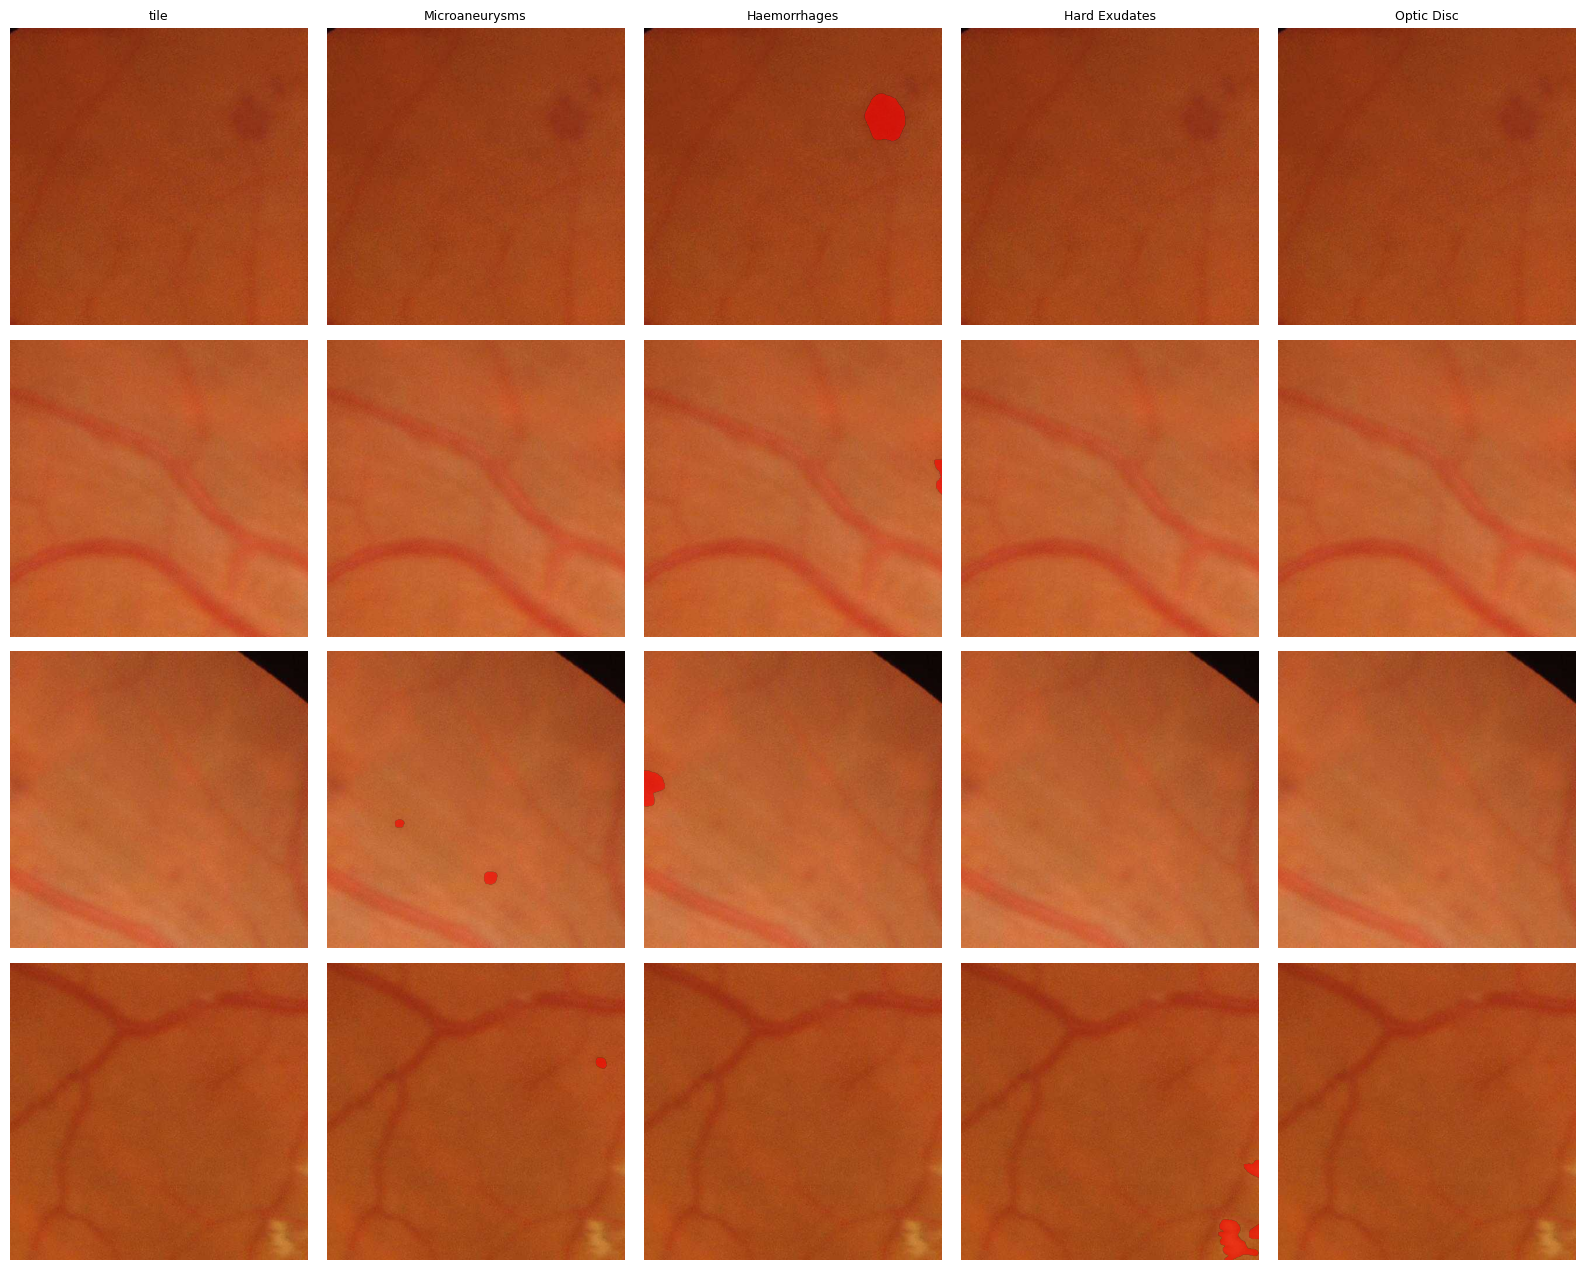

saved tile_check.png


In [7]:
import matplotlib.pyplot as plt
print('Per-class positive-pixel share in TRAIN (unmasked):')
for ci,cls in enumerate(CLASSES):
    frac=Ytr_u[...,ci].mean()
    print(f'  {cls:<16} {frac*100:.4f}% of tile pixels | tiles with class: {(Ytr_u[...,ci].reshape(len(Ytr_u),-1).any(1)).sum()}')

# show a few positive tiles with overlays
pos=[i for i in range(len(Xtr_u)) if Ytr_u[i].any()][:4]
fig,axes=plt.subplots(len(pos),5,figsize=(16,3.2*len(pos)))
cols=['tile']+CLASSES
for r,i in enumerate(pos):
    axes[r,0].imshow(Xtr_u[i]); axes[r,0].axis('off')
    if r==0: axes[r,0].set_title('tile',fontsize=9)
    for ci,cls in enumerate(CLASSES):
        axes[r,ci+1].imshow(Xtr_u[i]); axes[r,ci+1].imshow(np.ma.masked_where(Ytr_u[i,...,ci]==0,Ytr_u[i,...,ci]),alpha=0.6,cmap='autumn')
        axes[r,ci+1].axis('off')
        if r==0: axes[r,ci+1].set_title(cls,fontsize=9)
plt.tight_layout(); plt.savefig(f'{OUT}/tile_check.png',dpi=110,bbox_inches='tight'); plt.show()
print('saved tile_check.png')